## This is the code to Analyze the Neighbour Influence 1 Experiment

By default, if you play this file directly, it will generate the radius vs Average influence difference plot with respect to our experiment result.

**The idea of this analysis code is that: We obtain the influence list from the estimation code, and we obtain the neighbour distance by simply constructing the exact same dataset here. Then the distance can be computed by pairwise Euclidean distance. Finally, we map the neighbour distance with the influence difference.**

**Guideline**:  
Construct the exactly same dataset as the influence list that you wish to explore -> Read in the corresponding Influence lists -> Compute the pairwise Euclidean distance between each training sample -> Split the neighbour distance into 4 radius ranges -> Compute the average influence scores difference between neighbours -> Turn the results into the corresponding plot

**Format**:  
**Input** The Influence lists that you read in and the corresponding dataset.  
**Output**  The Radius vs Average influence difference Plot 

IF you want to test on other influence lists, remember, you need to change both the read_csv part and the dataset to the new data. Always make sure the dataset you use for influence estimation is the same here.

In [62]:
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras.utils import to_categorical
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [63]:
from keras import Sequential
from keras.layers import Dense, BatchNormalization, Dropout
from keras.losses import CategoricalCrossentropy
from keras.optimizers import Adam

In [64]:
from deel.influenciae.common import InfluenceModel, ExactIHVP
from deel.influenciae.influence import FirstOrderInfluenceCalculator
from deel.influenciae.utils import ORDER
from deel.influenciae.trac_in import TracIn

In [65]:
import random
from keras.optimizers import SGD

In [66]:
from sklearn.datasets import make_classification
from sklearn.datasets import make_blobs

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

1. We construct the exactly same dataset as the one used to generate influence here. The reason is that we need to examine the neighbour distance here and then compute the influence difference across neighbours. We won't give detailed explanation to the dataset again here.

In [68]:
train_pool = 16000
test_size = 500
train_sizes=[1000,2000,3000,4000,5000,6000,7000,8000,9000,10000]
n_features=160
seed=42
sep = 5

In [69]:
total_samples = train_pool + test_size

X, y = make_classification(n_samples=total_samples,
                           n_features=n_features,
                           n_informative=n_features,
                           n_redundant=0,
                           n_repeated=0,
                           n_classes=2,
                           class_sep=sep,
                           random_state=seed)

In [70]:
df = pd.DataFrame(X, columns=[f'feature_{i+1}' for i in range(n_features)])
df['label'] = y
df['id'] = np.arange(1, len(df) + 1)
print(df)

       feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0     -11.782908  -8.132727  16.152943  -9.137928   4.798538 -31.164432   
1       4.337057  -3.322490  -5.760765  -4.599484  13.619708  -0.447431   
2      -6.162488  10.509963   8.350375   3.877896  10.781976  -3.668239   
3       1.279108  -2.215843   5.809480  -6.197446   4.975266  -9.387154   
4       2.271039  -3.547205   1.348749 -10.493556  10.239804  -7.990558   
...          ...        ...        ...        ...        ...        ...   
16495  -6.716227  -3.941982   6.511306  -1.178930 -10.376654  -9.079567   
16496   4.277247 -15.312607  10.519820  -0.178716  -3.619789 -10.264994   
16497  -8.898158   2.233196  -6.868816  -1.021291   9.341948  15.122732   
16498  -3.610179 -17.301590   2.750310   6.510539  -0.240444  -2.099331   
16499 -17.536142   5.698689   9.265016   3.931781   6.659502  10.521925   

       feature_7  feature_8  feature_9  feature_10  ...  feature_153  \
0       8.887783  -4.063796

In [71]:
df_train_pool = df.iloc[:train_pool].reset_index(drop=True)
df_test = df.iloc[train_pool:].reset_index(drop=True)

In [72]:
print(df_train_pool.head())
print(df_test.head())

   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0 -11.782908  -8.132727  16.152943  -9.137928   4.798538 -31.164432   
1   4.337057  -3.322490  -5.760765  -4.599484  13.619708  -0.447431   
2  -6.162488  10.509963   8.350375   3.877896  10.781976  -3.668239   
3   1.279108  -2.215843   5.809480  -6.197446   4.975266  -9.387154   
4   2.271039  -3.547205   1.348749 -10.493556  10.239804  -7.990558   

   feature_7  feature_8  feature_9  feature_10  ...  feature_153  feature_154  \
0   8.887783  -4.063796  21.086774   -1.520991  ...     7.819484    -8.721757   
1  -2.525553   9.558629   7.793142    4.989492  ...     0.182679    -0.204365   
2 -17.248069   6.155376   3.674610    8.811081  ...     7.133064    16.611964   
3 -16.208869   2.459683  20.384366   11.957595  ...     6.951633     2.328660   
4 -16.237140  15.315085  12.821372   -1.751887  ...     4.459658     5.218489   

   feature_155  feature_156  feature_157  feature_158  feature_159  \
0    -0.265044  

In [73]:
features_to_test = 10
selected_features = [f'feature_{i+1}' for i in range(features_to_test)]

nested_train_dfs = [df_train_pool.iloc[:size].reset_index(drop=True) for size in train_sizes]
nested_train_dfs = [df[ selected_features + ['label', 'id'] ].copy()for df in nested_train_dfs]

df_test = df_test[ selected_features + ['label', 'id'] ].copy()

core_1000_ids = nested_train_dfs[0]['id'].tolist()

In [74]:
train_df = nested_train_dfs[7]

In [75]:
X_train = train_df.drop(columns=["label"])
y_train = train_df["label"]
IDs = X_train["id"].values.reshape(-1, 1).astype(np.float32)
IDs = IDs  / 1e10

X_train = X_train.drop(columns=["id"]).values.astype(np.float32)
X_train = np.hstack((X_train, IDs))
y_train = to_categorical(y_train.values,num_classes=2)

print(X_train)

[[-1.1782908e+01 -8.1327267e+00  1.6152943e+01 ...  2.1086775e+01
  -1.5209914e+00  1.0000000e-10]
 [ 4.3370576e+00 -3.3224895e+00 -5.7607651e+00 ...  7.7931418e+00
   4.9894924e+00  2.0000000e-10]
 [-6.1624880e+00  1.0509963e+01  8.3503752e+00 ...  3.6746099e+00
   8.8110809e+00  3.0000000e-10]
 ...
 [-1.4916819e+00  5.0382886e+00  9.9716389e-01 ...  8.7654905e+00
   7.6593747e+00  7.9979998e-07]
 [-1.3282650e+01 -1.0506052e+01 -3.9409058e+00 ...  4.6283894e+00
  -1.0233556e+00  7.9990002e-07]
 [-2.8309395e+00 -4.9407962e-01 -7.2877922e+00 ...  1.8293860e+00
   4.5104752e+00  8.0000001e-07]]


In [76]:
test_df = df_test
X_test = test_df.drop(columns=["label"])
y_test = test_df["label"]
IDs = X_test["id"].values.reshape(-1, 1).astype(np.float32)
IDs = IDs  / 1e10

X_test = X_test.drop(columns=["id"]).values.astype(np.float32)
X_test = np.hstack((X_test, IDs))
y_test = to_categorical(y_test.values,num_classes=2)

print(X_test)

[[ 8.1867008e+00  1.7569758e+00 -3.5113528e+00 ...  1.1672101e+01
   1.3301909e+01  1.6000999e-06]
 [ 1.4967977e+01 -5.7221599e+00  3.9504085e+00 ...  5.2967482e+00
  -4.2414246e+00  1.6002000e-06]
 [-9.9884319e+00 -4.0550404e+00 -1.1535553e-01 ...  1.5152292e+00
   6.7602162e+00  1.6003000e-06]
 ...
 [-8.8981581e+00  2.2331958e+00 -6.8688164e+00 ... -8.6201030e-01
   1.0897712e+00  1.6498000e-06]
 [-3.6101794e+00 -1.7301590e+01  2.7503097e+00 ... -8.9493771e+00
  -1.6968405e+01  1.6499000e-06]
 [-1.7536142e+01  5.6986890e+00  9.2650166e+00 ... -2.4410927e+00
   1.3462665e+01  1.6499999e-06]]


2. After we construct the dataset, we read in the corresponding ranked influence list. **The one you generated in the estimation code using exactly the same dataset as above.** We need the score to compute the influence difference between neighbours.

In [77]:
print(X_train.shape)

(8000, 11)


In [78]:
ranked_df = pd.read_csv("TC_Train_Set_8_seed42.csv")

In [79]:
ranked_sorted = ranked_df.sort_values("Train_ID")
print(ranked_sorted)

      Train_ID     Score
112          1  0.000462
1650         2  0.000076
3148         3  0.000013
3308         4  0.000010
3338         5  0.000009
...        ...       ...
2656      7996  0.000025
7911      7997 -0.001110
1225      7998  0.000121
426       7999  0.000283
5386      8000 -0.000002

[8000 rows x 2 columns]


In [80]:
print(X_train[:,-1:])

[[1.000e-10]
 [2.000e-10]
 [3.000e-10]
 ...
 [7.998e-07]
 [7.999e-07]
 [8.000e-07]]


In [81]:
infl_train = ranked_sorted["Score"].to_numpy(dtype=np.float64)
print(infl_train.shape)

(8000,)


3. The Pairwise distance between each training sample is then computed to find out the close neighbours distance. Radius is determined here to cover only the real neighbour initially.

In [82]:
from sklearn.neighbors import BallTree
from sklearn.metrics import pairwise_distances

In [83]:
D = pairwise_distances(X_train, metric="euclidean")
tri = D[np.triu_indices_from(D, k=1)]

In [84]:
r_cap = tri.max()
radius_ratios = [0.05, 0.10, 0.20, 0.30, 0.40]
radii = [r * r_cap for r in radius_ratios]

In [85]:
print(r_cap)

94.310745


In [86]:
# r_cap = tri.max()
# tri_cap = tri[tri <= r_cap]
# radii = np.quantile(tri_cap, [0.20, 0.40, 0.60, 0.80, 1.00])
# print("Shell bounds (≤ max/2):", np.round(radii, 4))

In [87]:
# radii = [5,6,7,8,9]

In [88]:
tree = BallTree(X_train, metric="euclidean")

4. Then we find the average influence difference between neighbours and then increase the radius. The corresponding plot is then generated.

In [89]:
records = []
prev_r = 0.0
for r in radii:
    inds_list, dists_list = tree.query_radius(X_train, r=r, return_distance=True, sort_results=False)
    diffs = []
    covered = 0
    for i, (nbrs, dists) in enumerate(zip(inds_list, dists_list)):
        mask = (dists > prev_r) & (dists <= r)
        nbrs = nbrs[mask]
        nbrs = nbrs[nbrs != i]
        if nbrs.size > 0:
            diffs.append(np.mean(np.abs(infl_train[i] - infl_train[nbrs])))
            covered += 1

    avg_diff = np.mean(diffs) if diffs else np.nan
    coverage = covered / len(X_train)
    records.append({"radius": r, "shell_from": prev_r, "avg_inf_diff": avg_diff, "coverage": coverage})

    prev_r = r


In [90]:
summary = pd.DataFrame(records)
print(summary)

      radius  shell_from  avg_inf_diff  coverage
0   4.715537    0.000000      0.000024  0.000500
1   9.431075    4.715537      0.000148  0.158375
2  18.862149    9.431075      0.000156  0.984750
3  28.293224   18.862149      0.000180  1.000000
4  37.724298   28.293224      0.000192  1.000000


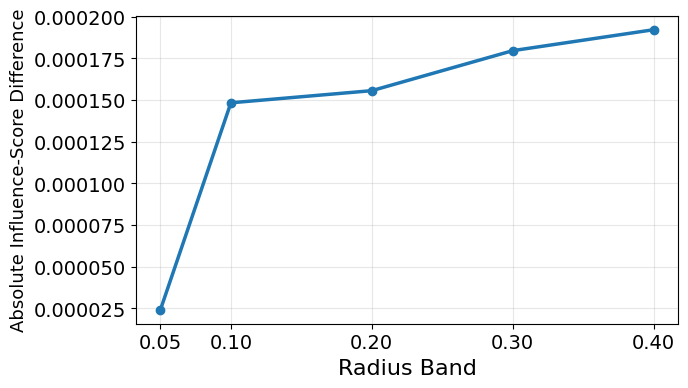

In [91]:


plt.figure(figsize=(7,4))
plt.plot(radius_ratios, summary["avg_inf_diff"], marker="o", linewidth=2.5)

plt.xlabel("Radius Band", fontsize=16)
plt.ylabel("Absolute Influence-Score Difference", fontsize=13)

plt.xticks(radius_ratios, fontsize=14)
plt.yticks(fontsize=14)

plt.savefig(
    "Neighbour_Synthetic_TC.png",
    dpi=600,
    bbox_inches="tight"
)
plt.grid(True, alpha=0.3)
plt.show()